# Series de tiempo

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import kagglehub
import os
from statsmodels.tsa.seasonal import seasonal_decompose

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


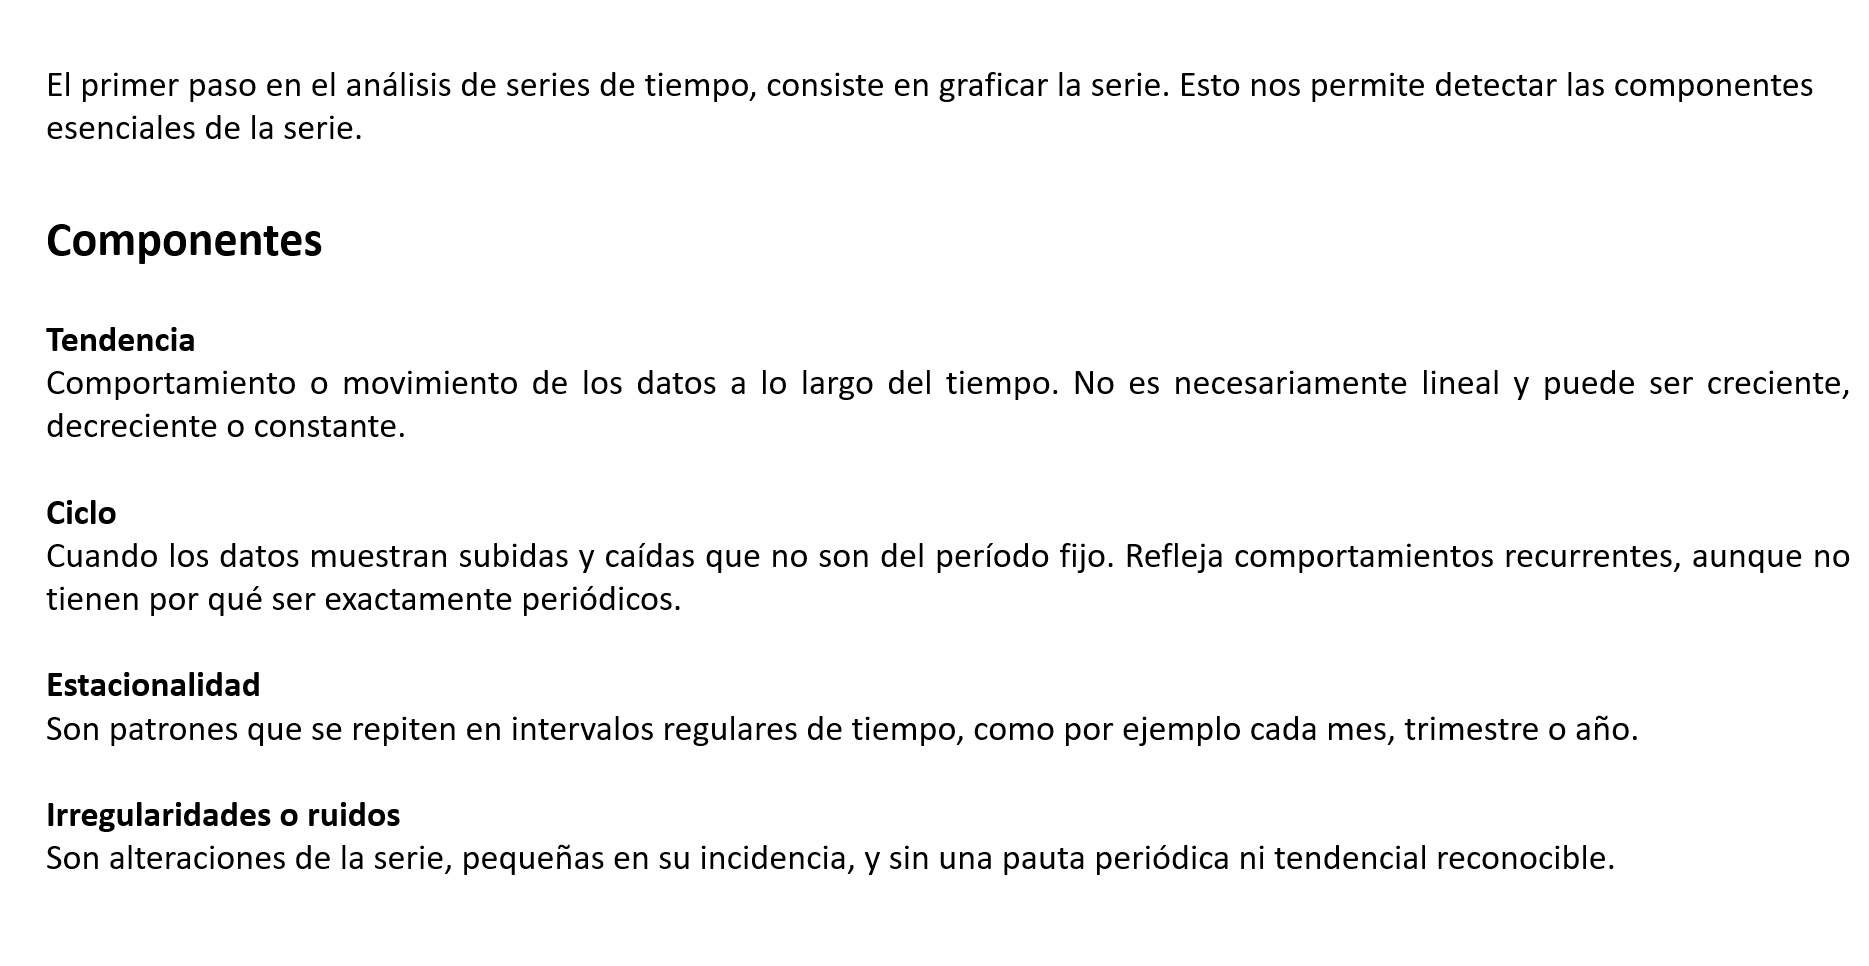

# COVID-19

Se trata de datos sobre hospitalizaciones por COVID-19 en el estado de California (CA) de EE. UU. desde el 01/02/2020 hasta el 31/12/2020, proporcionados por la Universidad Johns Hopkins con un intervalo de muestreo diario.

In [13]:
df = pd.read_csv('/content/drive/MyDrive/Estadistica/EstadisticaII/Sistemas/UnidadIII/archive/covid.csv')
df

,date,1,2,3,4,5,6,7,8,9,...,46,47,48,49,50,51,52,53,54,55
0,2020/2/1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2020/2/2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2020/2/3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020/2/4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2020/2/5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,2020/12/27,453.0,9.0,84.0,3.0,14.0,280.0,3.0,28.0,666.0,...,145.0,77.0,363.0,22.0,0.0,220.0,8.0,358.0,29.0,69.0
331,2020/12/28,473.0,9.0,77.0,1.0,14.0,260.0,2.0,26.0,677.0,...,146.0,78.0,367.0,23.0,0.0,230.0,9.0,365.0,24.0,67.0
332,2020/12/29,481.0,10.0,73.0,3.0,7.0,262.0,3.0,29.0,652.0,...,155.0,84.0,345.0,22.0,0.0,230.0,11.0,371.0,22.0,72.0
333,2020/12/30,496.0,10.0,83.0,4.0,6.0,271.0,4.0,29.0,621.0,...,150.0,90.0,343.0,22.0,0.0,227.0,10.0,384.0,25.0,98.0


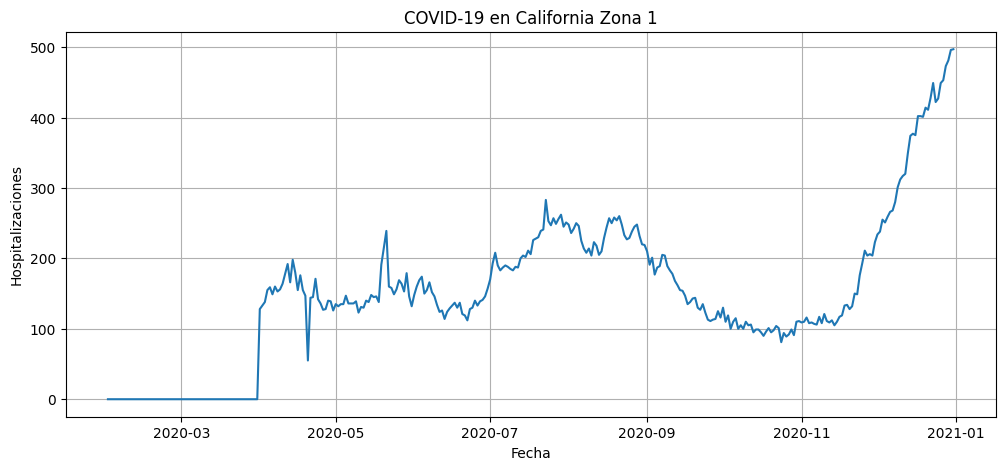

In [14]:
df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["1"])

plt.title("COVID-19 en California Zona 1")
plt.xlabel("Fecha")
plt.ylabel("Hospitalizaciones")
plt.grid(True)

plt.show()

### Tendencia

In [29]:
def regresion(x, y):
  #algunos valores
  n = np.size(x)
  sum_xy = np.sum(x*y)
  sum_x = np.sum(x)
  sum_y = np.sum(y)
  sum_x2 = np.sum(x**2)
  x_barra = np.sum(x)/n
  y_barra = np.sum(y)/n
  SXY = sum_xy - (sum_y*sum(x))/(n)
  SXX = sum_x2- (sum_x**2)/(n)

  #coeficientes y recta
  B1 = SXY/SXX
  B0 = y_barra - B1*x_barra
  y_estimados = B0 + B1*x #grafica

  print('Mi recta de regresión es', B0, '+', B1, 'x')

  #Correlación
  SYY = np.sum((y - y_barra)**2)
  r = SXY/(np.sqrt(SXX*SYY))
  print('r es', r)

  return B0, B1, y_estimados, r


In [30]:
#tiempo
x = np.arange(len(df))
#hospitalizaciones
y = df["1"].values

B0, B1, y_estimados, r = regresion(x, y)

Mi recta de regresión es 33.75986140724949 + 0.7033952351161217 x
r es 0.6546090498290478


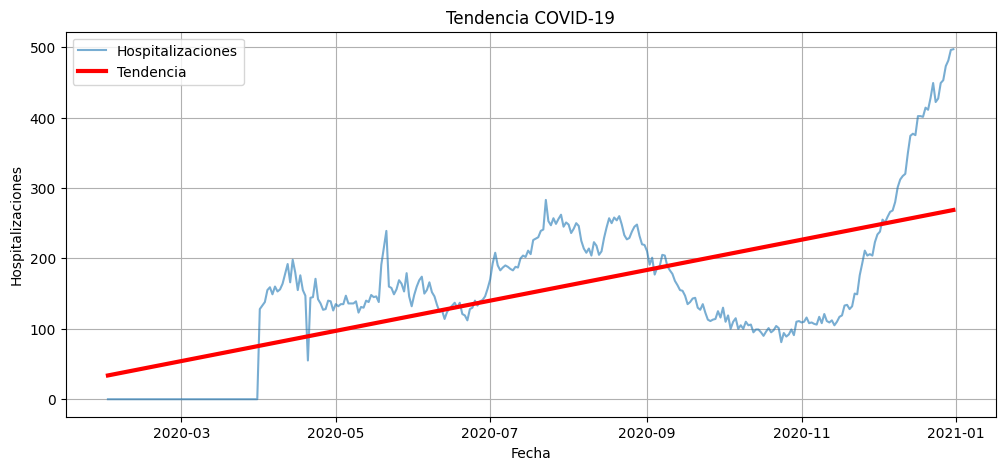

In [26]:
plt.figure(figsize=(12,5))


plt.plot(df["date"], y, label="Hospitalizaciones", alpha=0.6)
plt.plot(df["date"], y_estimados, color="red", linewidth=3, label="Tendencia")

plt.title("Tendencia COVID-19")
plt.xlabel("Fecha")
plt.ylabel("Hospitalizaciones")
plt.legend()
plt.grid(True)
plt.show()

### Estacionalidad

In [36]:
residuos = y - y_estimados
df["residuos"] = residuos

df["date"] = pd.to_datetime(df["date"])
df["dia_semana"] = df["date"].dt.day_name()

In [35]:
promedios = df.groupby("dia_semana")["1"].mean()
print('Promedios por ', promedios)

Promedios por  dia_semana
Friday       149.510638
Monday       145.895833
Saturday     145.562500
Sunday       146.604167
Thursday     159.229167
Tuesday      154.020833
Wednesday    157.729167
Name: 1, dtype: float64


In [39]:
promedios_estacionales = df.groupby("dia_semana")["residuos"].mean()
print('promedios estacionales', promedios_estacionales)

promedios estacionales dia_semana
Friday      -1.716227
Monday      -4.979335
Saturday    -3.905878
Sunday      -3.567606
Thursday     6.243813
Tuesday      2.442270
Wednesday    5.447208
Name: residuos, dtype: float64


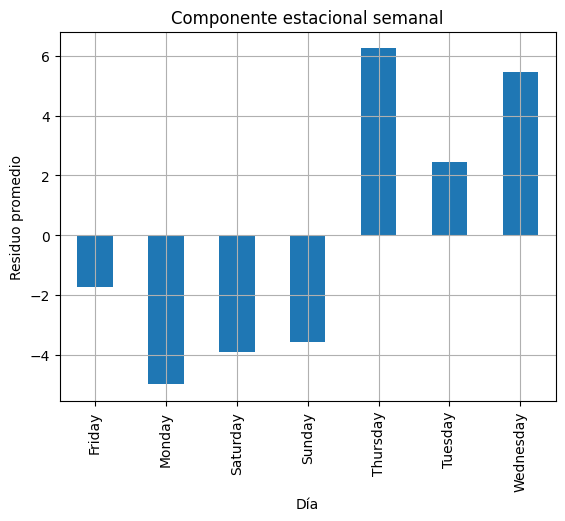

In [38]:
promedios_estacionales.plot(kind="bar")
plt.title("Componente estacional semanal")
plt.xlabel("Día")
plt.ylabel("Residuo promedio")
plt.grid(True)
plt.show()

### Ruido

Componente aleatoria

$A(t)=X(t)−T(t)−E(t)$

In [41]:
df["estacionalidad"] = df["dia_semana"].map(promedios_estacionales)

In [46]:
df["ruido"] = y - y_estimados - df["estacionalidad"]
print('Media del ruido', df["ruido"].mean())

Media del ruido 2.714909557531129e-15


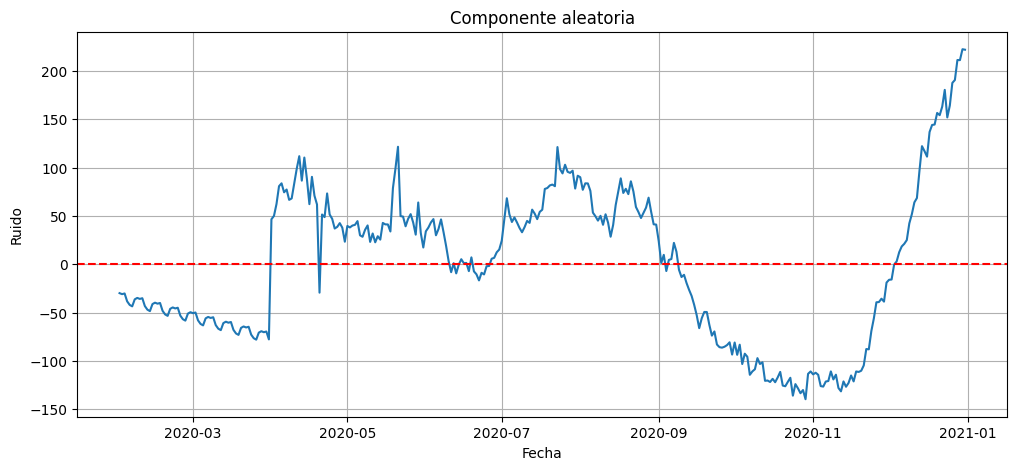

In [44]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["ruido"])

plt.axhline(0, color='red', linestyle='--')

plt.title("Componente aleatoria")
plt.xlabel("Fecha")
plt.ylabel("Ruido")

plt.grid(True)
plt.show()

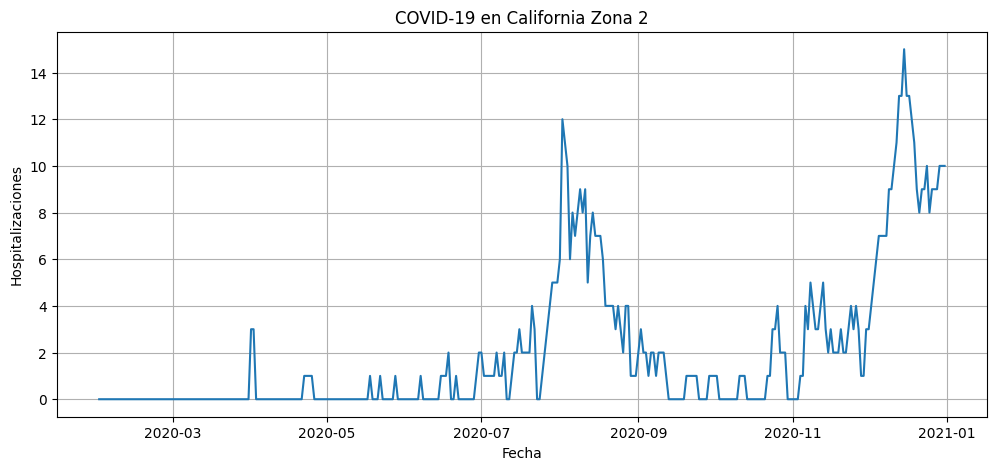

In [47]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["2"])

plt.title("COVID-19 en California Zona 2")
plt.xlabel("Fecha")
plt.ylabel("Hospitalizaciones")
plt.grid(True)

plt.show()

# Tráfico

Contiene datos de tráfico por hora de 963 carriles de autopistas de San Francisco para pronósticos a corto plazo, mientras que para pronósticos a largo plazo incluye datos de 862 carriles. Se recopila desde el 1 de enero de 2015 con un intervalo de muestreo de una hora.

In [48]:
df_trafico = pd.read_csv('/content/drive/MyDrive/Estadistica/EstadisticaII/Sistemas/UnidadIII/archive/traffic.csv')
df_trafico

,date,0,1,2,3,4,5,6,7,8,...,852,853,854,855,856,857,858,859,860,OT
0,2016-07-01 02:00:00,0.0048,0.0146,0.0289,0.0142,0.0064,0.0232,0.0162,0.0242,0.0341,...,0.0051,0.0051,0.0074,0.0079,0.0051,0.0051,0.0339,0.0051,0.0100,0.0121
1,2016-07-01 03:00:00,0.0072,0.0148,0.0350,0.0174,0.0084,0.0240,0.0201,0.0338,0.0434,...,0.0036,0.0036,0.0107,0.0058,0.0036,0.0036,0.0348,0.0036,0.0087,0.0136
2,2016-07-01 04:00:00,0.0040,0.0101,0.0267,0.0124,0.0049,0.0170,0.0127,0.0255,0.0332,...,0.0030,0.0030,0.0043,0.0050,0.0030,0.0030,0.0327,0.0030,0.0061,0.0107
3,2016-07-01 05:00:00,0.0039,0.0060,0.0218,0.0090,0.0029,0.0118,0.0088,0.0163,0.0211,...,0.0033,0.0033,0.0019,0.0052,0.0033,0.0033,0.0292,0.0033,0.0040,0.0071
4,2016-07-01 06:00:00,0.0042,0.0055,0.0191,0.0082,0.0024,0.0095,0.0064,0.0087,0.0144,...,0.0049,0.0049,0.0011,0.0071,0.0049,0.0049,0.0264,0.0049,0.0040,0.0039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,2018-07-01 21:00:00,0.0342,0.0332,0.1378,0.0559,0.0165,0.0386,0.0457,0.0687,0.0716,...,0.0139,0.0179,0.0278,0.0280,0.0227,0.0375,0.0142,0.0201,0.0341,0.0429
17540,2018-07-01 22:00:00,0.0285,0.0253,0.0542,0.0485,0.0131,0.0331,0.0372,0.0569,0.0669,...,0.0116,0.0155,0.0201,0.0267,0.0207,0.0320,0.0122,0.0163,0.0306,0.0363
17541,2018-07-01 23:00:00,0.0276,0.0257,0.0551,0.0474,0.0121,0.0326,0.0381,0.0566,0.0675,...,0.0109,0.0142,0.0208,0.0252,0.0189,0.0287,0.0123,0.0152,0.0292,0.0325
17542,2018-07-02 00:00:00,0.0232,0.0229,0.0496,0.0435,0.0119,0.0297,0.0361,0.0517,0.0598,...,0.0092,0.0124,0.0219,0.0215,0.0169,0.0258,0.0096,0.0130,0.0252,0.0279


(22, 863)


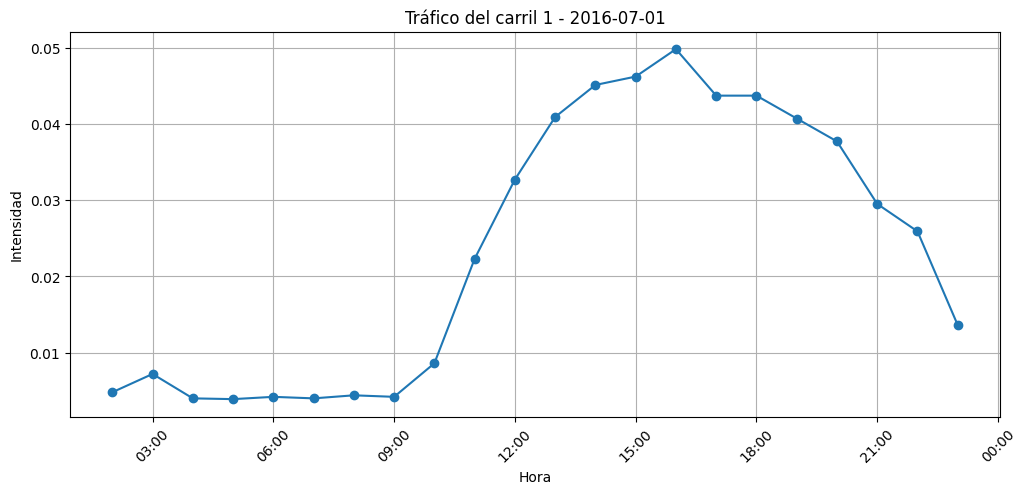

In [49]:
df_trafico["date"] = pd.to_datetime(df_trafico["date"])

dia = df_trafico[df_trafico["date"].dt.date == pd.to_datetime("2016-07-01").date()]
print(dia.shape)

plt.figure(figsize=(12,5))
plt.plot(dia["date"], dia["0"], marker='o')
plt.title("Tráfico del carril 1 - 2016-07-01")
plt.xlabel("Hora")
plt.ylabel("Intensidad")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

(22, 863)


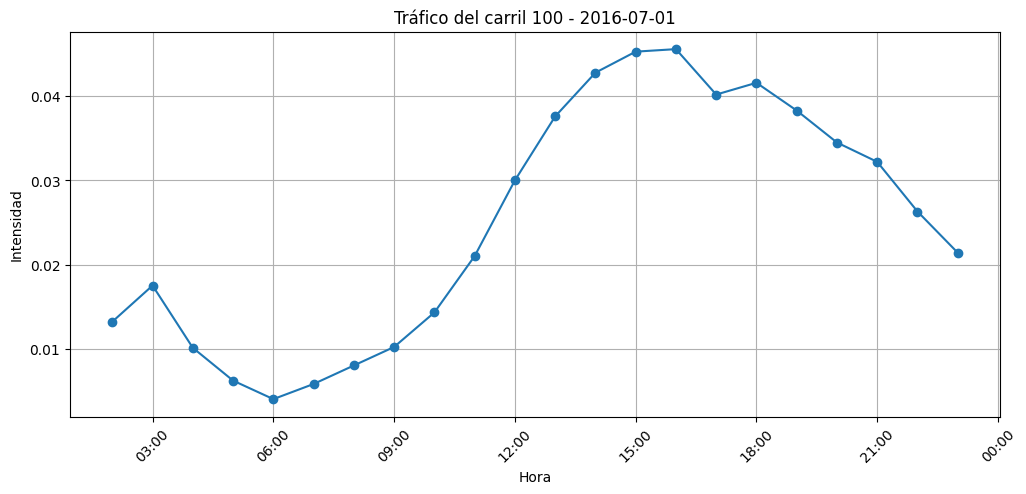

In [50]:
dia = df_trafico[df_trafico["date"].dt.date == pd.to_datetime("2016-07-01").date()]
print(dia.shape)

plt.figure(figsize=(12,5))
plt.plot(dia["date"], dia["99"], marker='o')
plt.title("Tráfico del carril 100 - 2016-07-01")
plt.xlabel("Hora")
plt.ylabel("Intensidad")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# Tipo de cambio

Contiene la recopilación de los tipos de cambio diarios de ocho países extranjeros, incluidos Australia, Reino Unido, Canadá, Suiza, China, Japón, Nueva Zelanda y Singapur, desde 1990 hasta 2016, con un intervalo de muestreo de datos de 1 día. (2)

In [51]:
df_cambio = pd.read_csv('/content/drive/MyDrive/Estadistica/EstadisticaII/Sistemas/UnidadIII/archive/exchange_rate.csv')
df_cambio

,date,1,2,3,4,5,6,7,8
0,1990/1/1,0.785500,1.611000,0.861698,0.634196,0.211242,0.006838,0.593000,0.525486
1,1990/1/2,0.781800,1.610000,0.861104,0.633513,0.211242,0.006863,0.594000,0.523972
2,1990/1/3,0.786700,1.629300,0.861030,0.648508,0.211242,0.006975,0.597300,0.526316
3,1990/1/4,0.786000,1.637000,0.862069,0.650618,0.211242,0.006953,0.597000,0.523834
4,1990/1/5,0.784900,1.653000,0.861995,0.656254,0.211242,0.006940,0.598500,0.527426
...,...,...,...,...,...,...,...,...,...
7583,2010/10/6,0.718494,1.222195,0.737485,0.969974,0.143697,0.008500,0.690846,0.688565
7584,2010/10/7,0.721839,1.223459,0.741155,0.977297,0.143763,0.008595,0.695701,0.690288
7585,2010/10/8,0.723197,1.234111,0.745184,0.984446,0.143997,0.008562,0.695943,0.691419
7586,2010/10/9,0.720825,1.233905,0.744131,0.980344,0.143993,0.008555,0.692689,0.690942


In [52]:
df_cambio["date"] = pd.to_datetime(df_cambio["date"])
df_cambio.set_index("date", inplace=True)

/tmp/ipykernel_13328/1151348527.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mensual = df_cambio["1"].resample("M").mean()


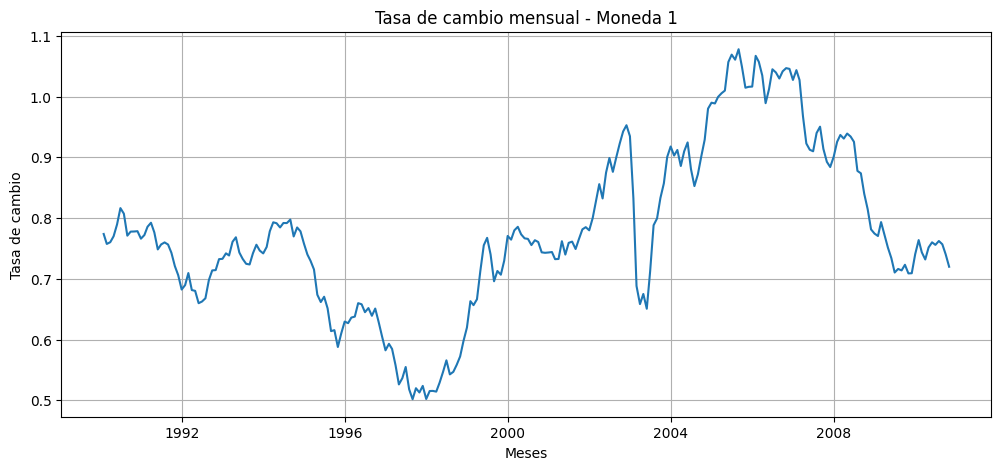

In [53]:
mensual = df_cambio["1"].resample("M").mean()

plt.figure(figsize=(12,5))
plt.plot(mensual.index, mensual.values)

plt.title("Tasa de cambio mensual - Moneda 1")
plt.xlabel("Meses")
plt.ylabel("Tasa de cambio")
plt.grid(True)
plt.show()

/tmp/ipykernel_13328/3403142842.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mensual = periodo["1"].resample("M").mean()


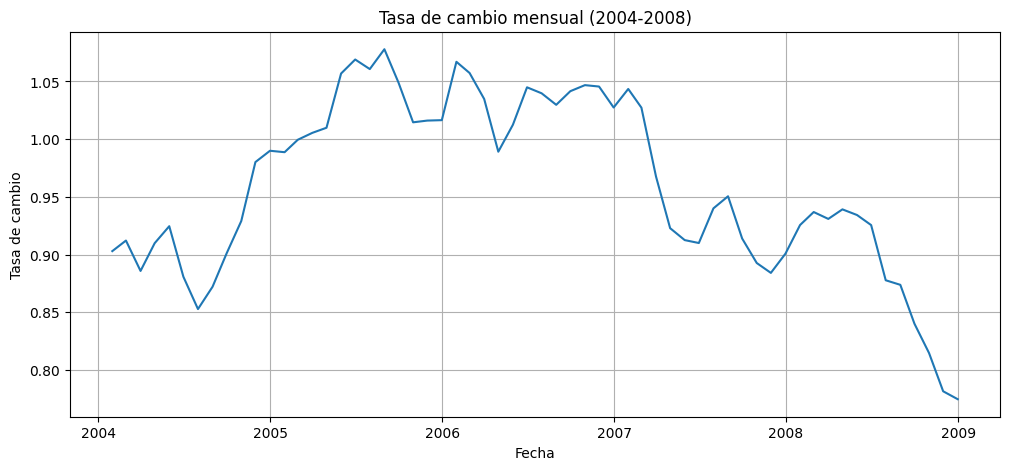

In [54]:
periodo = df_cambio.loc["2004-01-01":"2008-12-31"]

mensual = periodo["1"].resample("M").mean()

plt.figure(figsize=(12,5))

plt.plot(mensual.index, mensual.values)

plt.title("Tasa de cambio mensual (2004-2008)")
plt.xlabel("Fecha")
plt.ylabel("Tasa de cambio")
plt.grid(True)

plt.show()

# Clima

Recopila 21 indicadores meteorológicos, como la humedad y la temperatura del aire, de la estación meteorológica del Instituto Max Planck de Biogeoquímica en Alemania en 2020. El intervalo de muestreo de datos es de 10 minutos. (3)

In [55]:
df_clima = pd.read_csv('/content/drive/MyDrive/Estadistica/EstadisticaII/Sistemas/UnidadIII/archive/weather.csv')
df_clima

,date,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),...,wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m�),PAR (�mol/m�/s),max. PAR (�mol/m�/s),Tlog (degC),OT
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45,428.1
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51,428.0
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60,427.6
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70,430.0
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81,432.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52691,2020-12-31 23:20:00,978.32,2.28,277.16,-0.80,80.0,7.20,5.76,1.44,3.67,...,0.73,1.40,180.6,0.0,0.0,0.0,0.0,0.0,13.40,433.0
52692,2020-12-31 23:30:00,978.30,2.13,277.01,-0.43,83.1,7.12,5.92,1.20,3.77,...,0.43,0.82,174.0,0.0,0.0,0.0,0.0,0.0,13.42,439.6
52693,2020-12-31 23:40:00,978.26,1.99,276.88,-0.71,82.2,7.05,5.80,1.26,3.69,...,0.38,0.76,248.9,0.0,0.0,0.0,0.0,0.0,13.45,435.2
52694,2020-12-31 23:50:00,978.26,2.07,276.95,-0.77,81.4,7.09,5.77,1.32,3.68,...,0.57,1.07,196.6,0.0,0.0,0.0,0.0,0.0,13.47,433.9
